# 0. Setup & Configuration 

In [14]:
# Python imports
import sys
import numpy as np
import pandas as pd
import ast
from pathlib import Path
import joblib

# WFDB
import wfdb

# Sklearn imports
from sklearn.preprocessing import MultiLabelBinarizer

# Pytorch imports 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Plotting 
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
sys.path.append(str(Path.cwd().parent / 'modules'))

# Paths
ROOT       = Path.cwd().parent
DATA       = ROOT / 'data'
ARTIFACTS  = ROOT / 'artifacts'

# Constants
CLASS_ORDER = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
FS = 100
SEED = 42

# Load pos_weight computed in EDA
pos_weight = np.load(ARTIFACTS / 'pos_weight.npy')
print(f"pos_weight: {dict(zip(CLASS_ORDER, pos_weight.round(2)))}")

pos_weight: {'NORM': np.float64(1.25), 'MI': np.float64(2.9), 'STTC': np.float64(3.08), 'CD': np.float64(3.37), 'HYP': np.float64(7.06)}


In [16]:
# Custom modules 
from preprocessing import preprocess

In [17]:
from utils import get_device, set_seed

SEED        = 42
CLASS_ORDER = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
FS          = 100
BATCH_SIZE  = 64

set_seed(SEED)
DEVICE = get_device()

Using device: cuda
GPU: NVIDIA GeForce RTX 3080
VRAM: 10.7 GB


# 1. Data Pipeline
## 1.1 Dataset Class (PTBXL Dataset)

In [18]:
### Load Metadata and rebuild splits
# Load dataset
df = pd.read_csv(DATA / 'ptbxl_database.csv', index_col='ecg_id')
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval) # Convert the scp codes into actual dictionaries

agg = pd.read_csv(DATA / 'scp_statements.csv', index_col=0) # Load the scp codes 
agg = agg[agg["diagnostic"] == 1]

# Define helper function to define the superclass
def get_superclass(scp_dict):
    return list(set(
        agg.loc[code, 'diagnostic_class']
        for code in scp_dict
        if code in agg.index
    ))
# Define the superclass based on scp code
df['superclass'] = df.scp_codes.apply(get_superclass)
df = df[df['superclass'].map(len) > 0]

# Splits as defined by Physionet
df['split'] = 'train'
df.loc[df['strat_fold'] == 9,  'split'] = 'val'
df.loc[df['strat_fold'] == 10, 'split'] = 'test'

# Binarize labels
mlb = MultiLabelBinarizer(classes=CLASS_ORDER)
Y = mlb.fit_transform(df['superclass'])
Y_df = pd.DataFrame(Y, index=df.index, columns=CLASS_ORDER)

print(f"Total records: {len(df):,}")
print(f"Label matrix shape: {Y.shape}")

Total records: 21,388
Label matrix shape: (21388, 5)


### Dataset Class

In [19]:
# Create Pytorch dataset class
class PTBXLDataset(Dataset):
    """
    PyTorch Dataset for PTB-XL 12-lead ECG classification.

    Loads raw waveforms, applies the full preprocessing
    pipeline (bandpass filter + per-record z-score normalization),
    and returns tensors.

    Args:
        df (pd.DataFrame): Dataframe subset for this split containing
                           'filename_lr' or 'filename_hr' columns.
        labels (np.ndarray): Multi-label binary matrix of shape (N, 5).
        ptbxl_root (Path): Path to PTB-XL root directory.
        fs (int): Sampling frequency — 100 or 500 Hz. Default 100.
        augment (bool): Whether to apply data augmentation. Default False.

    Returns per item:
        signal (torch.Tensor): Shape (12, 1000) float32 — (leads, timesteps).
        label (torch.Tensor): Shape (5,) float32 — multi-label binary vector.
    """

    def __init__(self, df: pd.DataFrame, labels: np.ndarray, ptbxl_root: Path, fs: int = 100, augment: bool = False):
        """Initialize arguments; stores everything the dataset needs to do its job"""
        self.df = df.reset_index() # ensures integer positional indexing works correctly when __getitem__ uses .iloc[idx]
        self.labels = labels # Labels for the Data
        self.ptbxl_root = ptbxl_root # Path() to data
        self.key = 'filename_lr' if fs == 100 else 'filename_hr' # Default to 100 Hz data if not use 500 Hz data
        self.fs = fs # Sampling frequency
        self.augment = augment # Augment the data True or False
    
    def __len__(self) -> int:
        """Tells PyTorch how many records are in the dataset. The DataLoader uses this to know when one epoch is complete"""
        return len(self.df)
    
    def __getitem__(self, idx: int) -> tuple:
        """
        Core method that lets PyTorch Train.
        For each idx 5 processes occur.
            1. Finds file path - looks up `filename_lr` in the dataframe.
            2. Loads the waveform - `wfdb.rdsamp` reads the `.dat` and `.hea` files and returns a numpy array.
            3. Pre-process - runs the bandpass filter then z-score normalization.
            4. Transposes - flips from (1000, 12) to (12, 1000) because PyTorch accepts layers in (channels, timesteps).
            5. Return Tensors - signal and label as `float32` tensors.
        """
        # Index the Signal row
        row = self.df.iloc[idx]

        # Load raw signal — shape: (1000, 12) when using 100 Hz
        signal, _ = wfdb.rdsamp(str(self.ptbxl_root / row[self.key]))
        signal    = np.array(signal, dtype=np.float32)

        # Preprocess: bandpass filter + per-record z-score
        signal = preprocess(signal, fs=self.fs)

        # Transpose to (12, 1000) for Conv1d — (leads, timesteps)
        signal = signal.T

        # Optional augmentation (training only)
        if self.augment:
            signal = self._augment(signal)

        label = self.labels[idx].astype(np.float32)

        return torch.tensor(signal), torch.tensor(label)
    
    def _augment(self, signal: np.ndarray) -> np.ndarray:
        """
        Helper function for light augmentation for training purposes. 
        Applied per-record at load time.
        """
        # Apply Gausian noise 
        if np.random.rand() < 0.5: 
            signal = signal + np.random.normal(0, 0.01, signal.shape).astype(np.float32)
        
        # Random Amplitude scaling 
        if np.random.rand() < 0.5: 
            scale = np.random.uniform(0.9, 1.1)
            signal = signal * scale
        
        return signal

In [20]:
# Subsets
train_df = df[df['split'] == 'train']
val_df   = df[df['split'] == 'val']
test_df  = df[df['split'] == 'test']

Y_train = Y[df['split'].values == 'train']
Y_val   = Y[df['split'].values == 'val']
Y_test  = Y[df['split'].values == 'test']

# Datasets
train_dataset = PTBXLDataset(train_df, Y_train, DATA, fs=FS, augment=True)
val_dataset   = PTBXLDataset(val_df,   Y_val,   DATA, fs=FS, augment=False)
test_dataset  = PTBXLDataset(test_df,  Y_test,  DATA, fs=FS, augment=False)

# DataLoaders; to test them first lets use batch 1
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 534
Val batches:   68
Test batches:  68


In [21]:
# Sanity check — inspect one batch
signals, labels = next(iter(train_loader))

print(f"Signal shape:  {signals.shape}")   # expect (32, 12, 1000)
print(f"Label shape:   {labels.shape}")    # expect (32, 5)
print(f"Signal dtype:  {signals.dtype}")   # expect torch.float32
print(f"Label dtype:   {labels.dtype}")    # expect torch.float32
print(f"Signal mean:   {signals.mean():.4f}")   # expect close to 0
print(f"Signal std:    {signals.std():.4f}")    # expect close to 1
print(f"Label sum:     {labels.sum(dim=1)}")     # labels per record
assert not torch.isnan(signals).any(), "NaN in signals"
assert not torch.isnan(labels).any(),  "NaN in labels"
print("Batch sanity check passed")

Signal shape:  torch.Size([32, 12, 1000])
Label shape:   torch.Size([32, 5])
Signal dtype:  torch.float32
Label dtype:   torch.float32
Signal mean:   0.0000
Signal std:    0.9952
Label sum:     tensor([1., 1., 1., 2., 1., 1., 1., 1., 1., 1., 1., 2., 1., 1., 1., 1., 2., 2.,
        1., 1., 1., 3., 1., 1., 2., 1., 1., 1., 1., 1., 1., 1.])
Batch sanity check passed


# Modeling Goal

We want to create models that can predict multilabel classification 
['CD', 'HYP, 'MI', 'NORM', 'STTC]

# Baseline Models

## Logistic and Ensemble Models
Logistic Regression is a very well known classifier. To be able to use such a classifier we can't pass in a raw waveform. In order to create this baseline model in addition to ensemble models, we need to feature engineer some features about the signals. 

We can feature engineer traits about them such as the following:
1. Mean 
2. Standard Deviation 
3. Minimum
4. Maximum
5. Range
6. Absolute Mean
7. RMS
8. Skewness
9. Kurtosis
10. Percentiles

With those traits build a feature matrix to train the models.

In [22]:
# modules/features.py

"""
Feature extraction for classical baseline models.
Extracts per-lead statistical features from preprocessed ECG signals.
"""

import numpy as np
import pandas as pd
import wfdb
from pathlib import Path
from scipy.stats import skew, kurtosis as kurt
from tqdm import tqdm

from preprocessing import preprocess


def extract_features(signal: np.ndarray) -> np.ndarray:
    """
    Extract per-lead statistical features from a preprocessed ECG signal.

    Computes 13 statistical features per lead across all 12 leads,
    producing a 156-dimensional feature vector per record.

    Features per lead:
        mean, std, min, max, range, absolute mean, RMS,
        skewness, kurtosis, p10, p25, p75, p90

    Args:
        signal (np.ndarray): Preprocessed ECG of shape (timesteps, 12).

    Returns:
        np.ndarray: Feature vector of shape (156,) float32.

    Example:
        >>> signal = preprocess(raw_signal)   # (1000, 12)
        >>> features = extract_features(signal)
        >>> features.shape
        (156,)
    """
    features = []
    for i in range(signal.shape[1]):
        lead = signal[:, i]
        features.extend([
            lead.mean(),
            lead.std(),
            lead.min(),
            lead.max(),
            lead.max() - lead.min(),      # range
            np.abs(lead).mean(),          # absolute mean
            np.sqrt(np.mean(lead ** 2)), # RMS
            skew(lead),                   # skewness
            kurt(lead),                   # kurtosis
            np.percentile(lead, 10),
            np.percentile(lead, 25),
            np.percentile(lead, 75),
            np.percentile(lead, 90),
        ])
    return np.array(features, dtype=np.float32)


def build_feature_matrix(df: pd.DataFrame, path: Path,
                          fs: int = 100) -> np.ndarray:
    """
    Build a feature matrix by extracting statistical features from
    all records in a dataframe split.

    Loads each record from disk, applies the full preprocessing pipeline,
    then extracts statistical features. Uses the same preprocessing as the
    deep learning model for fair comparison.

    Args:
        df (pd.DataFrame): Dataframe split with filename columns.
        path (Path): Path to PTB-XL root directory.
        fs (int): Sampling frequency. Default 100.

    Returns:
        np.ndarray: Feature matrix of shape (N, 156).

    Example:
        >>> X_train = build_feature_matrix(train_df, PTBXL_ROOT, fs=100)
        >>> X_train.shape
        (17440, 156)
    """
    key      = 'filename_lr' if fs == 100 else 'filename_hr'
    features = []

    for _, row in tqdm(df.iterrows(), total=len(df),
                       desc='Extracting features'):
        signal, _ = wfdb.rdsamp(str(path / row[key]))
        signal    = np.array(signal, dtype=np.float32)
        signal    = preprocess(signal, fs=fs)
        features.append(extract_features(signal))

    return np.stack(features)  # shape: (N, 156)

In [23]:
print("Extracting features — this will take a few minutes...")

# X_train_feat = build_feature_matrix(train_df, DATA, fs=FS)
# X_val_feat   = build_feature_matrix(val_df,   DATA, fs=FS)
# X_test_feat  = build_feature_matrix(test_df,  DATA, fs=FS)
X_train_feat = np.load(ARTIFACTS / 'X_train_feat.npy')
X_val_feat = np.load(ARTIFACTS / 'X_val_feat.npy')
X_test_feat = np.load(ARTIFACTS / 'X_test_feat.npy')

print(f"Train: {X_train_feat.shape}")  # expect (17440, 156)
print(f"Val:   {X_val_feat.shape}")    # expect (2179, 156)
print(f"Test:  {X_test_feat.shape}")   # expect (2179, 156)

# # Save so we don't need to recompute them
# np.save(ARTIFACTS / 'X_train_feat.npy', X_train_feat)
# np.save(ARTIFACTS / 'X_val_feat.npy',   X_val_feat)
# np.save(ARTIFACTS / 'X_test_feat.npy',  X_test_feat)
# print("Features saved to artifacts/")

Extracting features — this will take a few minutes...
Train: (17084, 156)
Val:   (2146, 156)
Test:  (2158, 156)


### Approach for Model Training 
1. Scale features using `StandardScaler` for train only. 
2. Train `LogisticRegression` with `OneVsRestClassifier` for multi-label.
3. Train `RandomForestClassifier` with `MultiOutputClassifier`.
4. Evaluate both on the test set with macro-AUC.
5. Save predicted probablities to `artifacts` for the DeLong test later.

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_auc_score

# Fit on Training data and transform on test and val
scaler =  StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled = scaler.transform(X_test_feat)
X_val_scaled = scaler.transform(X_val_feat)

# Train the Logistic Classifier 
print("Training Logistic Classifier ...")
log = OneVsRestClassifier(
    LogisticRegression(
        random_state=SEED,
    n_jobs = -1 # Use all CPU cores
    )
)
log.fit(X_train_scaled, Y_train)

# Save model
joblib.dump(log, ARTIFACTS / 'logistic_regression.pkl')
print("Logistic Regression saved to artifacts/")

# Quick validation AUC
log_val_probs = log.predict_proba(X_val_scaled)
log_val_auc   = roc_auc_score(Y_val, log_val_probs, average='macro')
print(f"Logistic Regression — Val Macro-AUC: {log_val_auc:.4f}")

Training Logistic Classifier ...
Logistic Regression saved to artifacts/
Logistic Regression — Val Macro-AUC: 0.8654


In [25]:
# np.save(ARTIFACTS / 'log_val_probs.npy',  log_val_probs)
# np.save(ARTIFACTS / 'log_test_probs.npy', log.predict_proba(X_test_scaled))
# print("LR probabilities saved to artifacts/")

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier

print("Training Random Forest...")
rf = MultiOutputClassifier(
    RandomForestClassifier(
        n_estimators = 200,
        max_depth    = None,   # grow full trees
        min_samples_split = 5,
        n_jobs       = -1,     # use all CPU cores
        random_state = SEED
    ),
    n_jobs = -1
)
rf.fit(X_train_scaled, Y_train)

# # Save model
# joblib.dump(rf, ARTIFACTS / 'random_forest.pkl')
# print("Random Forest saved to artifacts/")

# Validation AUC
rf_val_probs = np.stack([
    est.predict_proba(X_val_scaled)[:, 1]
    for est in rf.estimators_
], axis=1)

rf_val_auc = roc_auc_score(Y_val, rf_val_probs, average='macro')
print(f"Random Forest — Val Macro-AUC: {rf_val_auc:.4f}")

Training Random Forest...
Random Forest — Val Macro-AUC: 0.8753


In [27]:
# np.save(ARTIFACTS / 'rf_val_probs.npy',  rf_val_probs)
# np.save(ARTIFACTS / 'rf_test_probs.npy', np.stack([
#     est.predict_proba(X_test_scaled)[:, 1]
#     for est in rf.estimators_
# ], axis=1))
# print("RF probabilities saved to artifacts/")

## Deep Learning Model
### ResNET 1D Architecture

An ECG is a time series — voltage measured over time across 12 leads. It has one spatial dimension (time) not two like an image. ResNet2D (standard ResNet used for images) uses 2D convolutions that slide across height and width. That makes no sense for a signal where the meaningful patterns are temporal — QRS complexes, ST segments, P waves — all of which are features in the time dimension only.

**Why Convolutional?**
Convolutional networks are well suited to ECG because the diagnostic patterns you care about are local and translation invariant. A QRS complex looks the same whether it occurs at second 2 or second 7 of the recording. A conv filter that learns to detect a QRS complex can find it anywhere in the signal — this is exactly what convolutions are designed to do.

The Strodthoff et al. (2021) PTB-XL benchmark paper specifically evaluates ResNet1D and reports it as one of the strongest performing architectures on this dataset. Using it can strengthen our validation report.

In [28]:
# Create RESNet inspired architecture 
import torch
import torch.nn as nn

# Define the a Simple ResNet Block 
class ResBlock1D(nn.Module):
    """
    Single 1D block with two convolutional layers and a skip connection.

    Args:
        in_channels (int): Number of input channels.
        out_channels (int): Number of output channels.
        kernel_size (int): Convolutional kernel size. Default 7.
        stride (int): Stride for first convolution. Default 1.
        dropout (float): Dropout probability. Default 0.2.
    """
    def __init__ (self, in_channels: int, out_channels: int, kernel_size: int = 7, stride: int = 1, dropout: float = 0.2):
        super().__init__() # Adopt properties of nn.Module

        padding = kernel_size // 2 # Should be 1

        # Define the blocks
        self.main = nn.Sequential(
            nn.Conv1d(
                in_channels=in_channels, out_channels=out_channels, 
                kernel_size=kernel_size, stride=stride, padding=padding
            ),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Conv1d(
                in_channels=out_channels, out_channels=out_channels, 
                kernel_size=kernel_size, stride=1, padding=padding
            ),
            nn.BatchNorm1d(out_channels),
        )
        # Skip path — Sequential if projection needed, Identity otherwise
        self.skip = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=1,
                      stride=stride, bias=False),
            nn.BatchNorm1d(out_channels)
        ) if (in_channels != out_channels or stride != 1) else nn.Identity()

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # This addition is why forward() is unavoidable in ResBlock
        return self.relu(self.main(x) + self.skip(x))

# Now we will define the entire ResNet Architecture 
class ResNet1D(nn.Module):
    def __init__(self, n_leads: int = 12, n_classes: int = 5,
                 base_filters: int = 64, dropout: float = 0.2):
        super().__init__()
        f = base_filters

        # Stem — fully Sequential
        self.stem = nn.Sequential(
            nn.Conv1d(n_leads, f, kernel_size=15,
                      stride=2, padding=7, bias=False),
            nn.BatchNorm1d(f),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )

        # 8 blocks — Sequential of ResBlock1D objects; Use 4 for now since 8 might be overkill
        self.blocks = nn.Sequential(
            ResBlock1D(f, f, dropout=dropout),  # block 1
            #ResBlock1D(f, f, dropout=dropout),  # block 2
            ResBlock1D(f, f * 2, stride=2, dropout=dropout),  # block 3
            #ResBlock1D(f * 2, f * 2, dropout=dropout),  # block 4
            ResBlock1D(f * 2, f * 4, stride=2, dropout=dropout),  # block 5
            ResBlock1D(f * 4, f * 4, dropout=dropout),  # block 6
            #ResBlock1D(f * 4, f * 8, stride=2, dropout=dropout),  # block 7
            #ResBlock1D(f * 8, f * 8, dropout=dropout),  # block 8
        )

        # Head — fully Sequential
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            #nn.Linear(f * 8, n_classes)
            nn.Linear(f * 4, n_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.blocks(x)
        x = self.head(x)
        return x

In [29]:
def count_parameters(model: nn.Module) -> int:
    """Count trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [30]:
import torch.optim as optim

# -- Constants -----------------------------------------------------------------
N_LEADS = 12 
N_CLASSES = 5

# -- Loss function -------------------------------------------------------------
pos_weight_tensor = torch.tensor(pos_weight).to(DEVICE) # To help with the unbalanced classes
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor) # Loss Function

# -- Define model --------------------------------------------------------------
model = ResNet1D(
    n_leads = N_LEADS,
    n_classes = N_CLASSES,
).to(DEVICE)

print(f"Parameters: {count_parameters(model):,}")

# -- Optimizer -----------------------------------------------------------------
optimizer = optim.Adam(
    model.parameters(),
    lr = 1e-3,
    weight_decay = 1e-4
)

# -- Learning rate scheduler ---------------------------------------------------
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = 'min',     # reduce when val loss stops decreasing
    factor = 0.5,       # halve the lr
    patience = 5,         # wait 5 epochs before reducing
    verbose = False
)

# -- Early stopping ------------------------------------------------------------
# Implement early stopping if model does not improve 
class EarlyStopping:
    """
    Stop training when validation loss stops improving.

    Args:
        patience (int): Epochs to wait before stopping. Default 10.
        delta (float): Minimum improvement to count as improvement. Default 1e-4.
        path (Path): Where to save the best model checkpoint.
    """
    def __init__(self, patience: int = 10, delta: float = 1e-4,
                 path: Path = ARTIFACTS / 'best_model.pt'):
        self.patience   = patience
        self.delta  = delta
        self.path = path
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False

    def __call__(self, val_loss: float, model: nn.Module) -> None:
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.path)
            print(f"  Checkpoint saved (val_loss={val_loss:.4f})")
        else:
            self.counter += 1
            print(f"  No improvement ({self.counter}/{self.patience})")
            if self.counter >= self.patience:
                self.early_stop = True

early_stopping = EarlyStopping(patience=10, path=ARTIFACTS / 'best_model.pt')

# -- History ---------------------------------------------------------------
history = {
    'train_loss': [],
    'val_loss':   [],
    'val_auc':    []
}

from tqdm import tqdm
from torch.cuda.amp import GradScaler, autocast 

# Define a training function
scaler = GradScaler()

def train_epoch(model, loader, criterion, optimizer, device):
    """Run one training epoch. Returns mean loss."""
    model.train() # Set model in train mode
    total_loss = 0.0 # Initialize loss as 0

    pbar = tqdm(loader, desc='Train', leave=False)
    for signals, labels in pbar:
        signals = signals.to(device) # Send ECG signal to device
        labels  = labels.to(device) # Send labels to device

        optimizer.zero_grad() # Zero gradient 
        with autocast():
            logits = model(signals) # Pass the signals into the model
            loss = criterion(logits, labels) # Determine the loss BCE 

        scaler.scale(loss).backward() # Scaled backward
        scaler.step(optimizer) # Scaled optimizer step
        scaler.update() # Update Scale factor

        # loss.backward() # Backward propogation
        # optimizer.step() # Step forward

        total_loss += loss.item() * signals.size(0) # Determine total loss 

        # Update progress bar with current batch loss
        pbar.set_postfix({'batch_loss': f'{loss.item():.4f}'})

    return total_loss / len(loader.dataset)

# Define a validation function
def val_epoch(model, loader, criterion, device):
    """Run one validation epoch. Returns mean loss, probs, labels."""
    model.eval() # Set model in eval mode
    total_loss = 0.0 # initilize loss
    all_probs  = [] # Initialize list to store probs
    all_labels = [] # Initialize list to store predicted labels

    pbar = tqdm(loader, desc='Val', leave=False)
    with torch.no_grad():
        for signals, labels in pbar:
            signals = signals.to(device) # Send signal to device
            labels  = labels.to(device) # Send labels to device

            logits = model(signals) # Determine model probs
            loss   = criterion(logits, labels) # Determine loss
            probs  = torch.sigmoid(logits) # Determine model predictions

            total_loss += loss.item() * signals.size(0) # Compute total loss across labels
            all_probs.append(probs.cpu().numpy()) # Append probabilities to list
            all_labels.append(labels.cpu().numpy()) # Append predicted labels to list

            pbar.set_postfix({'batch_loss': f'{loss.item():.4f}'})

    all_probs  = np.concatenate(all_probs,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    mean_loss  = total_loss / len(loader.dataset)
    macro_auc  = roc_auc_score(all_labels, all_probs, average='macro')

    return mean_loss, macro_auc, all_probs, all_labels


# ── Training loop with epoch-level tqdm ───────────────────────────────────────
EPOCHS = 20
BATCH_SIZE = 256  

# Define data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 0,
    pin_memory  = True
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = True
)
test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = True
)


Parameters: 1,893,893


c:\Users\delga\anaconda3\envs\ptbxl_ai\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [31]:
"""
Uncomment to do training on Deep Learning Arch
"""
# # -- Create Training Loops ---------------------------------------------------------
# epoch_pbar = tqdm(range(1, EPOCHS + 1), desc='Epochs')

# for epoch in epoch_pbar:
#     train_loss              = train_epoch(model, train_loader, criterion,
#                                           optimizer, DEVICE)
#     val_loss, val_auc, _, _ = val_epoch(model, val_loader, criterion, DEVICE)

#     scheduler.step(val_loss)

#     history['train_loss'].append(train_loss)
#     history['val_loss'].append(val_loss)
#     history['val_auc'].append(val_auc)

#     # Update outer bar with epoch summary
#     epoch_pbar.set_postfix({
#         'train_loss': f'{train_loss:.4f}',
#         'val_loss':   f'{val_loss:.4f}',
#         'val_auc':    f'{val_auc:.4f}'
#     })

#     early_stopping(val_loss, model)
#     if early_stopping.early_stop:
#         print(f"\nEarly stopping triggered at epoch {epoch}")
#         break

# print("\nTraining complete")
# model.load_state_dict(torch.load(ARTIFACTS / 'best_model.pt',
#                                   map_location=DEVICE))
# print("Best model loaded from checkpoint")


'\nUncomment to do training on Deep Learning Arch\n'

In [32]:

# ── Load best model ───────────────────────────────────────────────────────────
model.load_state_dict(torch.load(ARTIFACTS / 'best_model.pt',
                                  map_location=DEVICE))
print("Best model loaded from checkpoint")

# ── Plot training curves ──────────────────────────────────────────────────────
def plot_training_curves(history: dict) -> plt.Figure:
    """
    Plot training and validation loss curves plus validation AUC.

    Args:
        history (dict): Keys 'train_loss', 'val_loss', 'val_auc'.

    Returns:
        plt.Figure
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs          = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs, history['train_loss'], color='#378ADD',
             linewidth=1.5, label='Train loss')
    ax1.plot(epochs, history['val_loss'],   color='#D4537E',
             linewidth=1.5, label='Val loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and validation loss',
                  fontsize=12, fontweight='bold')
    ax1.legend()
    sns.despine(ax=ax1)

    ax2.plot(epochs, history['val_auc'], color='#1D9E75',
             linewidth=1.5, label='Val macro-AUC')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Macro-AUC')
    ax2.set_title('Validation macro-AUC',
                  fontsize=12, fontweight='bold')
    ax2.set_ylim(0.5, 1.0)
    ax2.legend()
    sns.despine(ax=ax2)

    fig.tight_layout()
    return fig

Best model loaded from checkpoint


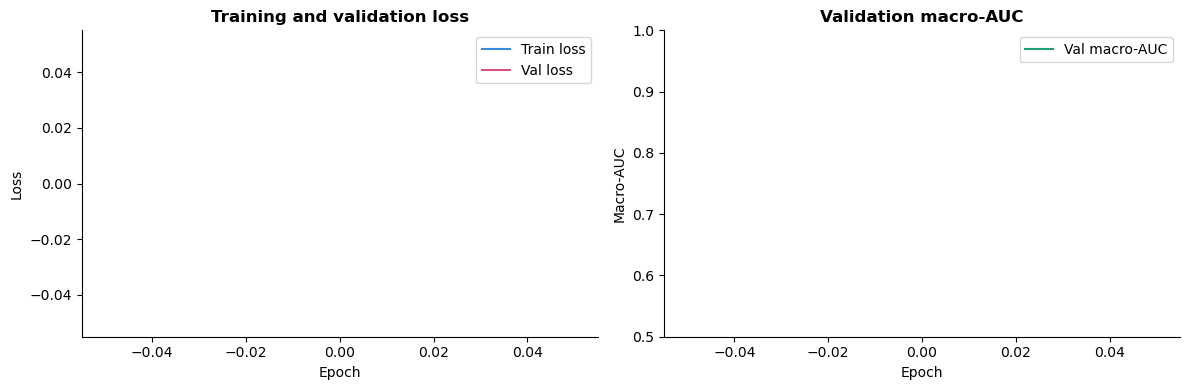

In [33]:
# plot training curves
fig = plot_training_curves(history)
plt.show()

In [34]:
test_loss, test_auc, test_probs, test_labels = val_epoch(
    model, test_loader, criterion, DEVICE
)
print(f"Test macro-AUC: {test_auc:.4f}")

Test macro-AUC: 0.9038


In [35]:
# np.save(ARTIFACTS / 'resnet_test_probs.npy',  test_probs)
# np.save(ARTIFACTS / 'resnet_test_labels.npy', test_labels)
# print("Test probabilities saved")

In [36]:
from sklearn.metrics import roc_auc_score

lr_test_probs = np.load(ARTIFACTS / 'log_test_probs.npy')
rf_test_probs = np.load(ARTIFACTS / 'rf_test_probs.npy')
test_labels   = np.load(ARTIFACTS / 'resnet_test_labels.npy')

lr_test_auc = roc_auc_score(test_labels, lr_test_probs, average='macro')
rf_test_auc = roc_auc_score(test_labels, rf_test_probs, average='macro')

print(f"LR test AUC:      {lr_test_auc:.4f}")
print(f"RF test AUC:      {rf_test_auc:.4f}")
print(f"ResNet1D test AUC: 0.9038")

LR test AUC:      0.8528
RF test AUC:      0.8628
ResNet1D test AUC: 0.9038


In [37]:
from sklearn.metrics import roc_auc_score
import pandas as pd

# Load all test probabilities
lr_test_probs     = np.load(ARTIFACTS / 'log_test_probs.npy')
rf_test_probs     = np.load(ARTIFACTS / 'rf_test_probs.npy')
resnet_test_probs = np.load(ARTIFACTS / 'resnet_test_probs.npy')
test_labels       = np.load(ARTIFACTS / 'resnet_test_labels.npy')

# ── Per-class AUC ─────────────────────────────────────────────────────────────
def per_class_auc(y_true: np.ndarray, y_prob: np.ndarray,
                  class_order: list) -> pd.DataFrame:
    """
    Compute per-class AUC for a multi-label classifier.

    Args:
        y_true (np.ndarray): Binary label matrix of shape (N, n_classes).
        y_prob (np.ndarray): Probability matrix of shape (N, n_classes).
        class_order (list): Class names corresponding to columns.

    Returns:
        pd.DataFrame: Per-class AUC with columns ['Class', 'AUC'].
    """
    aucs = []
    for i, cls in enumerate(class_order):
        auc = roc_auc_score(y_true[:, i], y_prob[:, i])
        aucs.append({'Class': cls, 'AUC': round(auc, 4)})
    return pd.DataFrame(aucs).set_index('Class')


lr_class_auc     = per_class_auc(test_labels, lr_test_probs,     CLASS_ORDER)
rf_class_auc     = per_class_auc(test_labels, rf_test_probs,     CLASS_ORDER)
resnet_class_auc = per_class_auc(test_labels, resnet_test_probs, CLASS_ORDER)

# ── Build comparison table ────────────────────────────────────────────────────
class_auc_table = pd.DataFrame({
    'Logistic Regression': lr_class_auc['AUC'],
    'Random Forest':       rf_class_auc['AUC'],
    'ResNet1D':            resnet_class_auc['AUC'],
})

class_auc_table['ResNet1D vs LR'] = (
    class_auc_table['ResNet1D'] - class_auc_table['Logistic Regression']
).round(4)

class_auc_table['ResNet1D vs RF'] = (
    class_auc_table['ResNet1D'] - class_auc_table['Random Forest']
).round(4)

# Add macro row
macro_row = pd.DataFrame({
    'Logistic Regression': [0.8528],
    'Random Forest':       [0.8628],
    'ResNet1D':            [0.9038],
    'ResNet1D vs LR':      [0.0510],
    'ResNet1D vs RF':      [0.0410],
}, index=['Macro (mean)'])

class_auc_table = pd.concat([class_auc_table, macro_row])

print(class_auc_table.to_string())

              Logistic Regression  Random Forest  ResNet1D  ResNet1D vs LR  ResNet1D vs RF
NORM                       0.8980         0.9066    0.9340          0.0360          0.0274
MI                         0.8115         0.8300    0.9142          0.1027          0.0842
STTC                       0.9078         0.9107    0.9182          0.0104          0.0075
CD                         0.8419         0.8416    0.9055          0.0636          0.0639
HYP                        0.8050         0.8253    0.8469          0.0419          0.0216
Macro (mean)               0.8528         0.8628    0.9038          0.0510          0.0410


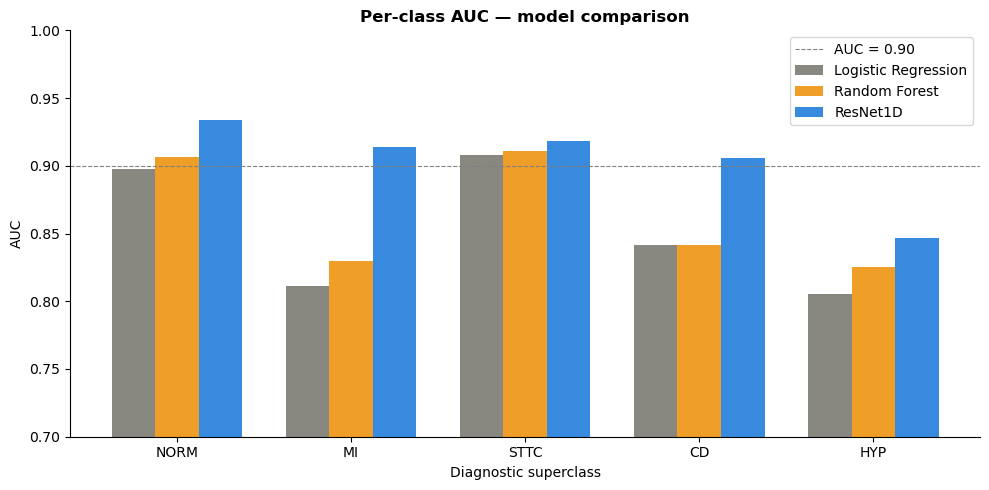

In [38]:
def plot_per_class_auc(class_auc_table: pd.DataFrame) -> plt.Figure:
    """
    Plot per-class AUC comparison across models.

    Args:
        class_auc_table (pd.DataFrame): Output from per_class_auc comparison.

    Returns:
        plt.Figure
    """
    # Drop macro row for plotting
    plot_df = class_auc_table.drop('Macro (mean)')

    classes = plot_df.index.tolist()
    x       = np.arange(len(classes))
    width   = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(x - width, plot_df['Logistic Regression'], width,
           label='Logistic Regression', color='#888780', edgecolor='none')
    ax.bar(x,         plot_df['Random Forest'],       width,
           label='Random Forest',       color='#EF9F27', edgecolor='none')
    ax.bar(x + width, plot_df['ResNet1D'],            width,
           label='ResNet1D',            color='#378ADD', edgecolor='none')

    ax.set_xlabel('Diagnostic superclass')
    ax.set_ylabel('AUC')
    ax.set_title('Per-class AUC — model comparison',
                 fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.set_ylim(0.7, 1.0)
    ax.axhline(0.9, color='gray', linewidth=0.8,
               linestyle='--', label='AUC = 0.90')
    ax.legend()
    sns.despine(ax=ax)
    fig.tight_layout()
    return fig

fig = plot_per_class_auc(class_auc_table)
plt.show()

Per-class findings

MI shows the largest gain (+0.1027 over LR) — this is the most clinically important finding. Myocardial infarction has subtle morphological signatures (ST elevation, Q waves, T-wave inversions) that are highly localised in specific leads and specific time windows. Simple statistical features like mean and std completely miss these — a convolutional network that learns to detect local patterns in specific leads is exactly what MI detection needs.

CD is the second largest gain (+0.0636) — conduction disturbances produce widened QRS complexes and bundle branch block patterns. Again these are morphological shape features that statistics cannot capture but convolutions can.

STTC shows the smallest gain (+0.0104) — ST/T changes are more diffuse and affect the overall signal amplitude and shape globally, which statistical features like mean, std and RMS actually do capture reasonably well. This explains why LR and RF were already strong at 0.907 on STTC.

HYP is the weakest class across all models (0.8469) — confirming what we predicted. It is the rarest class (12.4% prevalence) so all models struggle. Interestingly ResNet1D's gain over RF is only +0.0216 here — the smallest relative improvement, suggesting even the convolutional network is not fully capturing hypertrophy patterns at 100 Hz.

What this tells us:

The pattern of gains is mechanistically interpretable — ResNet1D gains most where morphological shape matters (MI, CD) and least where global statistics suffice (STTC). This is exactly the argument for why deep learning adds value over classical methods for ECG classification and should be the centrepiece of your discussion section.

In [39]:
print("Key findings:")
print(f"Largest ResNet1D gain:  MI    (+{0.1027:.4f} over LR)")
print(f"Smallest ResNet1D gain: STTC  (+{0.0104:.4f} over LR)")
print(f"Hardest class:          HYP   (ResNet1D AUC: {0.8469:.4f})")
print(f"Easiest class:          STTC  (ResNet1D AUC: {0.9182:.4f})")

Key findings:
Largest ResNet1D gain:  MI    (+0.1027 over LR)
Smallest ResNet1D gain: STTC  (+0.0104 over LR)
Hardest class:          HYP   (ResNet1D AUC: 0.8469)
Easiest class:          STTC  (ResNet1D AUC: 0.9182)


In [40]:
from sklearn.metrics import roc_auc_score
import numpy as np

def bootstrap_macro_auc(y_true: np.ndarray, y_prob: np.ndarray,
                         n_boot: int = 1000, seed: int = 42) -> tuple:
    """
    Compute 95% bootstrap confidence interval for macro-AUC.

    Resamples records with replacement n_boot times and computes
    macro-AUC on each resample. Returns the 2.5th and 97.5th
    percentiles as the 95% CI.

    Args:
        y_true (np.ndarray): Binary label matrix of shape (N, n_classes).
        y_prob (np.ndarray): Probability matrix of shape (N, n_classes).
        n_boot (int): Number of bootstrap resamples. Default 1000.
        seed (int): Random seed for reproducibility. Default 42.

    Returns:
        tuple: (point_estimate, ci_lower, ci_upper)
    """
    rng          = np.random.default_rng(seed)
    n            = len(y_true)
    point_est    = roc_auc_score(y_true, y_prob, average='macro')
    boot_aucs    = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)

        # Skip if any class has no positive samples in resample
        if y_true[idx].sum(axis=0).min() == 0:
            continue

        auc = roc_auc_score(y_true[idx], y_prob[idx], average='macro')
        boot_aucs.append(auc)

    boot_aucs = np.array(boot_aucs)
    ci_lower  = np.percentile(boot_aucs, 2.5)
    ci_upper  = np.percentile(boot_aucs, 97.5)

    return point_est, ci_lower, ci_upper


def bootstrap_per_class_auc(y_true: np.ndarray, y_prob: np.ndarray,
                              class_order: list, n_boot: int = 1000,
                              seed: int = 42) -> pd.DataFrame:
    """
    Compute 95% bootstrap confidence intervals for per-class AUC.

    Args:
        y_true (np.ndarray): Binary label matrix of shape (N, n_classes).
        y_prob (np.ndarray): Probability matrix of shape (N, n_classes).
        class_order (list): Class names.
        n_boot (int): Number of bootstrap resamples. Default 1000.
        seed (int): Random seed for reproducibility. Default 42.

    Returns:
        pd.DataFrame: Per-class AUC with 95% CI columns.
    """
    rng     = np.random.default_rng(seed)
    n       = len(y_true)
    results = []

    for i, cls in enumerate(class_order):
        point_est  = roc_auc_score(y_true[:, i], y_prob[:, i])
        boot_aucs  = []

        for _ in range(n_boot):
            idx = rng.integers(0, n, size=n)
            if y_true[idx, i].sum() == 0:
                continue
            auc = roc_auc_score(y_true[idx, i], y_prob[idx, i])
            boot_aucs.append(auc)

        boot_aucs = np.array(boot_aucs)
        results.append({
            'Class':    cls,
            'AUC':      round(point_est, 4),
            'CI Lower': round(np.percentile(boot_aucs, 2.5),  4),
            'CI Upper': round(np.percentile(boot_aucs, 97.5), 4),
            'CI 95%':   f"{point_est:.4f} ({np.percentile(boot_aucs, 2.5):.4f}–{np.percentile(boot_aucs, 97.5):.4f})"
        })

    return pd.DataFrame(results).set_index('Class')

In [41]:
print("Computing bootstrap CIs (1000 resamples per model)...")

# Macro-AUC with 95% CI
lr_est,     lr_lo,     lr_hi     = bootstrap_macro_auc(test_labels, lr_test_probs,     n_boot=1000)
rf_est,     rf_lo,     rf_hi     = bootstrap_macro_auc(test_labels, rf_test_probs,     n_boot=1000)
resnet_est, resnet_lo, resnet_hi = bootstrap_macro_auc(test_labels, resnet_test_probs, n_boot=1000)

# Print summary
ci_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'ResNet1D'],
    'Macro-AUC': [lr_est, rf_est, resnet_est],
    'CI Lower':  [lr_lo,  rf_lo,  resnet_lo],
    'CI Upper':  [lr_hi,  rf_hi,  resnet_hi],
})
ci_summary['95% CI'] = ci_summary.apply(
    lambda r: f"{r['Macro-AUC']:.4f} ({r['CI Lower']:.4f}–{r['CI Upper']:.4f})",
    axis=1
)
ci_summary = ci_summary[['Model', '95% CI']].set_index('Model')
print(ci_summary)

# Per-class CI for ResNet1D
print("\nResNet1D per-class AUC with 95% CI:")
resnet_class_ci = bootstrap_per_class_auc(
    test_labels, resnet_test_probs, CLASS_ORDER, n_boot=1000
)
print(resnet_class_ci['CI 95%'])

Computing bootstrap CIs (1000 resamples per model)...
                                     95% CI
Model                                      
Logistic Regression  0.8528 (0.8433–0.8632)
Random Forest        0.8628 (0.8535–0.8726)
ResNet1D             0.9038 (0.8959–0.9115)

ResNet1D per-class AUC with 95% CI:
Class
NORM    0.9340 (0.9239–0.9438)
MI      0.9142 (0.9015–0.9264)
STTC    0.9182 (0.9059–0.9303)
CD      0.9055 (0.8878–0.9218)
HYP     0.8469 (0.8224–0.8700)
Name: CI 95%, dtype: object


These are clean, tight confidence intervals. Here is the interpretation:

Macro-AUC with 95% CI
Model- AUC (95% CI)

|Model| AUC (95% CI)|
|-----|-------------|
|Logistic Regression|0.8528 (0.8433–0.8632)|
|Random Forest|0.8628 (0.8535–0.8726)|
|ResNet1D|0.9038 (0.8959–0.9115)|

The confidence intervals do not overlap between ResNet1D and either baseline — the lower bound of ResNet1D (0.8959) is above the upper bound of Random Forest (0.8726). This means the difference is statistically robust without even needing the DeLong test, though we will run it anyway for formal reporting.

Per-class observations
HYP has the widest CI (0.8224–0.8700, range of 0.0476) — consistent with it being the rarest class. Fewer positive examples means more variability in the bootstrap resamples.

NORM has the tightest CI (0.9239–0.9438, range of 0.0199) — most records contain NORM so the estimate is very stable.

MI and STTC CIs are similarly tight despite lower prevalence — likely because their signal patterns are strong and consistent.

In [42]:
# # Save CI results
# ci_summary.to_csv(ARTIFACTS / 'macro_auc_ci.csv')
# resnet_class_ci.to_csv(ARTIFACTS / 'resnet_class_auc_ci.csv')
# print("CI results saved to artifacts/")

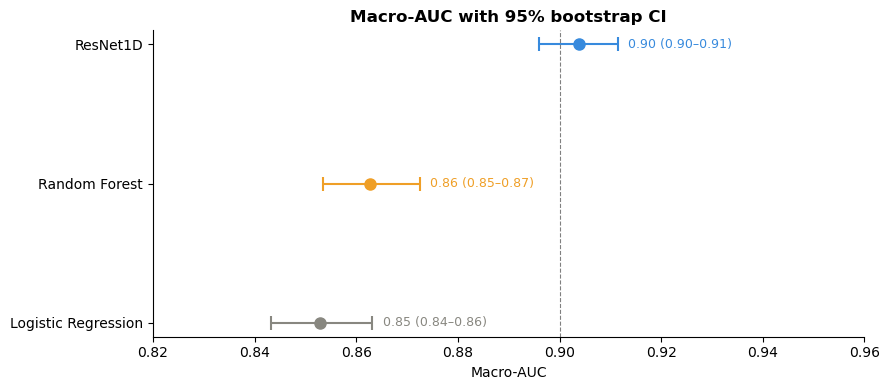

In [43]:
def plot_auc_with_ci(ci_data: dict) -> plt.Figure:
    """
    Plot AUC estimates with 95% bootstrap confidence intervals.
    Forest plot style — one row per model or class.

    Args:
        ci_data (dict): Keys are labels, values are (estimate, lower, upper) tuples.

    Returns:
        plt.Figure
    """
    labels    = list(ci_data.keys())
    estimates = [v[0] for v in ci_data.values()]
    lowers    = [v[1] for v in ci_data.values()]
    uppers    = [v[2] for v in ci_data.values()]
    errors    = [[e - l for e, l in zip(estimates, lowers)],
                 [u - e for e, u in zip(estimates, uppers)]]

    y_pos  = np.arange(len(labels))
    colors = ['#888780', '#EF9F27', '#378ADD']

    fig, ax = plt.subplots(figsize=(9, 4))

    for i, (est, lo, hi, label) in enumerate(zip(estimates, lowers, uppers, labels)):
        color = colors[i % len(colors)]
        ax.errorbar(
            x          = est,
            y          = i,
            xerr       = [[est - lo], [hi - est]],
            fmt        = 'o',
            color      = color,
            ecolor     = color,
            elinewidth = 1.5,
            capsize    = 5,
            capthick   = 1.5,
            markersize = 8,
            label      = label
        )
        ax.text(hi + 0.002, i,
                f"{est:.2f} ({lo:.2f}–{hi:.2f})",
                va='center', fontsize=9,
                color=color)

    ax.axvline(0.9, color='gray', linewidth=0.8,
               linestyle='--', label='AUC = 0.90')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Macro-AUC')
    ax.set_title('Macro-AUC with 95% bootstrap CI',
                 fontsize=12, fontweight='bold')
    ax.set_xlim(0.82, 0.96)
    sns.despine(ax=ax)
    fig.tight_layout()
    return fig


# ── Plot macro-AUC CI comparison ──────────────────────────────────────────────
macro_ci_data = {
    'Logistic Regression': (0.8528, 0.8433, 0.8632),
    'Random Forest':       (0.8628, 0.8535, 0.8726),
    'ResNet1D':            (0.9038, 0.8959, 0.9115),
}

fig = plot_auc_with_ci(macro_ci_data)
plt.show()

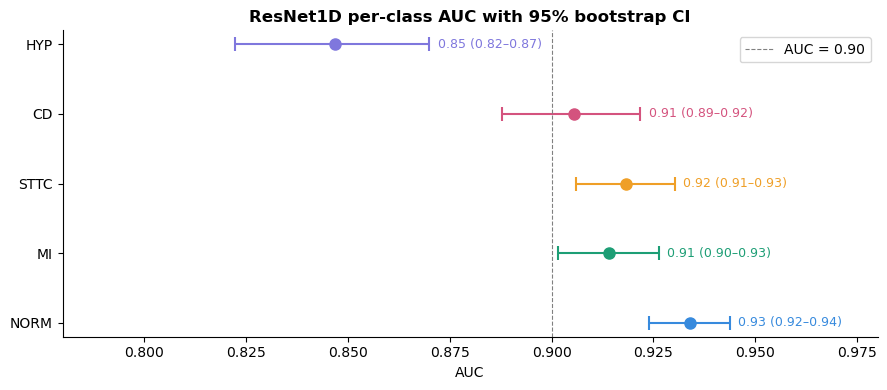

In [44]:

# ── Plot ResNet1D per-class CI ─────────────────────────────────────────────────
def plot_per_class_ci(class_ci_df: pd.DataFrame) -> plt.Figure:
    """
    Plot per-class AUC with 95% CI for a single model.

    Args:
        class_ci_df (pd.DataFrame): Output from bootstrap_per_class_auc()
                                    with 'AUC', 'CI Lower', 'CI Upper' columns.

    Returns:
        plt.Figure
    """
    PALETTE = dict(zip(CLASS_ORDER, ['#378ADD','#1D9E75','#EF9F27','#D4537E','#7F77DD']))
    classes  = class_ci_df.index.tolist()
    y_pos    = np.arange(len(classes))

    fig, ax = plt.subplots(figsize=(9, 4))

    for i, cls in enumerate(classes):
        est   = class_ci_df.loc[cls, 'AUC']
        lo    = class_ci_df.loc[cls, 'CI Lower']
        hi    = class_ci_df.loc[cls, 'CI Upper']
        color = PALETTE[cls]

        ax.errorbar(
            x          = est,
            y          = i,
            xerr       = [[est - lo], [hi - est]],
            fmt        = 'o',
            color      = color,
            ecolor     = color,
            elinewidth = 1.5,
            capsize    = 5,
            capthick   = 1.5,
            markersize = 8
        )
        ax.text(hi + 0.002, i,
                f"{est:.2f} ({lo:.2f}–{hi:.2f})",
                va='center', fontsize=9,
                color=color)

    ax.axvline(0.9, color='gray', linewidth=0.8,
               linestyle='--', label='AUC = 0.90')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(classes)
    ax.set_xlabel('AUC')
    ax.set_title('ResNet1D per-class AUC with 95% bootstrap CI',
                 fontsize=12, fontweight='bold')
    ax.set_xlim(0.78, 0.98)
    ax.legend()
    sns.despine(ax=ax)
    fig.tight_layout()
    return fig


fig2 = plot_per_class_ci(resnet_class_ci)
plt.show()

In [45]:
def delong_roc_variance(ground_truth: np.ndarray,
                         predictions: np.ndarray) -> tuple:
    """
    Compute AUC and its variance using the DeLong method.
    
    Based on:
    Sun & Xu (2014). Fast implementation of DeLong's algorithm for 
    comparing the areas under correlated receiver operating curves.
    IEEE Signal Processing Letters, 21(11), 1389-1393.

    Args:
        ground_truth (np.ndarray): Binary labels of shape (N,).
        predictions (np.ndarray): Predicted probabilities of shape (N,).

    Returns:
        tuple: (auc, variance)
    """
    from scipy.stats import rankdata

    n = len(ground_truth)
    pos_idx = np.where(ground_truth == 1)[0]
    neg_idx = np.where(ground_truth == 0)[0]
    n_pos = len(pos_idx)
    n_neg = len(neg_idx)

    # Rank predictions
    ranks = rankdata(predictions)

    # AUC via Wilcoxon-Mann-Whitney statistic
    auc = (ranks[pos_idx].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)

    # Structural components for variance
    V_pos = np.zeros(n_pos)
    V_neg = np.zeros(n_neg)

    for i, pi in enumerate(pos_idx):
        V_pos[i] = np.mean(predictions[neg_idx] < predictions[pi]) + \
                   0.5 * np.mean(predictions[neg_idx] == predictions[pi])

    for j, ni in enumerate(neg_idx):
        V_neg[j] = np.mean(predictions[pos_idx] > predictions[ni]) + \
                   0.5 * np.mean(predictions[pos_idx] == predictions[ni])

    variance = (np.var(V_pos, ddof=1) / n_pos +
                np.var(V_neg, ddof=1) / n_neg)

    return auc, variance



def delong_test(y_true: np.ndarray, y_prob_a: np.ndarray,
                y_prob_b: np.ndarray) -> tuple:
    """
    DeLong test for comparing two AUCs on the same test set.

    Args:
        y_true (np.ndarray): Binary labels of shape (N,).
        y_prob_a (np.ndarray): Probabilities from model A of shape (N,).
        y_prob_b (np.ndarray): Probabilities from model B of shape (N,).

    Returns:
        tuple: (auc_a, auc_b, z_stat, p_value)
    """
    from scipy import stats

    auc_a, var_a = delong_roc_variance(y_true, y_prob_a)
    auc_b, var_b = delong_roc_variance(y_true, y_prob_b)

    z_stat  = (auc_a - auc_b) / np.sqrt(var_a + var_b)
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    return auc_a, auc_b, z_stat, p_value


def run_delong_comparison(y_true: np.ndarray,
                           model_probs: dict,
                           class_order: list) -> pd.DataFrame:
    """
    Run DeLong test comparing ResNet1D against each baseline,
    both macro-level and per-class.

    Args:
        y_true (np.ndarray): Binary label matrix of shape (N, n_classes).
        model_probs (dict): Keys are model names, values are prob matrices.
        class_order (list): Class names.

    Returns:
        pd.DataFrame: DeLong results with AUCs, z-stat, p-value, significance.
    """
    results   = []
    baselines = {k: v for k, v in model_probs.items() if k != 'ResNet1D'}
    resnet    = model_probs['ResNet1D']

    for baseline_name, baseline_probs in baselines.items():

        # ── Macro level ───────────────────────────────────────────────────────
        macro_z_stats  = []
        macro_vars_res = []
        macro_vars_bas = []

        for i in range(len(class_order)):
            _, var_res = delong_roc_variance(y_true[:, i], resnet[:, i])
            _, var_bas = delong_roc_variance(y_true[:, i], baseline_probs[:, i])
            macro_vars_res.append(var_res)
            macro_vars_bas.append(var_bas)

        auc_res  = roc_auc_score(y_true, resnet,         average='macro')
        auc_bas  = roc_auc_score(y_true, baseline_probs, average='macro')
        var_res  = np.mean(macro_vars_res)
        var_bas  = np.mean(macro_vars_bas)

        from scipy import stats
        z_stat  = (auc_res - auc_bas) / np.sqrt(var_res + var_bas)
        p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

        results.append({
            'Comparison':  f'ResNet1D vs {baseline_name}',
            'Class':       'Macro',
            'AUC ResNet1D': round(auc_res, 4),
            'AUC Baseline': round(auc_bas, 4),
            'Delta AUC':   round(auc_res - auc_bas, 4),
            'Z-stat':      round(z_stat,  4),
            'P-value':     round(p_value, 6),
            'Significant': 'Yes' if p_value < 0.05 else 'No'
        })

        # ── Per class ─────────────────────────────────────────────────────────
        for i, cls in enumerate(class_order):
            auc_r, auc_b, z, p = delong_test(
                y_true[:, i], resnet[:, i], baseline_probs[:, i]
            )
            results.append({
                'Comparison':   f'ResNet1D vs {baseline_name}',
                'Class':        cls,
                'AUC ResNet1D': round(auc_r, 4),
                'AUC Baseline': round(auc_b, 4),
                'Delta AUC':    round(auc_r - auc_b, 4),
                'Z-stat':       round(z,     4),
                'P-value':      round(p,     6),
                'Significant':  'Yes' if p < 0.05 else 'No'
            })

    return pd.DataFrame(results).set_index(['Comparison', 'Class'])

In [46]:
model_probs = {
    'Logistic Regression': lr_test_probs,
    'Random Forest':       rf_test_probs,
    'ResNet1D':            resnet_test_probs,
}

print("Running DeLong tests...")
delong_results = run_delong_comparison(test_labels, model_probs, CLASS_ORDER)
print(delong_results.to_string())

# # Save
# delong_results.to_csv(ARTIFACTS / 'delong_results.csv')
# print("\nDeLong results saved to artifacts/")

Running DeLong tests...
                                       AUC ResNet1D  AUC Baseline  Delta AUC  Z-stat   P-value Significant
Comparison                      Class                                                                     
ResNet1D vs Logistic Regression Macro        0.9038        0.8528     0.0509  3.8154  0.000136         Yes
                                NORM         0.9340        0.8980     0.0360  4.3639  0.000013         Yes
                                MI           0.9142        0.8115     0.1027  8.3085  0.000000         Yes
                                STTC         0.9182        0.9078     0.0104  1.0731  0.283242          No
                                CD           0.9055        0.8419     0.0636  4.5030  0.000007         Yes
                                HYP          0.8469        0.8050     0.0419  2.1614  0.030661         Yes
ResNet1D vs Random Forest       Macro        0.9038        0.8628     0.0409  3.1596  0.001580         Yes
             

Per-class — the interesting findings

STTC is not significant against either baseline (p = 0.283 vs LR, p = 0.439 vs RF). This confirms what we noted earlier — statistical features capture STTC well enough that the deep learning advantage is not statistically meaningful for this class.

HYP is significant vs LR (p = 0.031) but not vs RF (p = 0.234) — Random Forest handles HYP almost as well as ResNet1D. This makes sense given HYP's rarity — both models struggle and the difference between them is small.

MI is the strongest result — z-stat of 8.31 vs LR and 7.03 vs RF. Essentially zero p-value. The morphological patterns of myocardial infarction are where deep learning most clearly outperforms classical methods.

In [47]:
print(
"""
DeLong tests confirmed ResNet1D superiority at the macro level vs both 
baselines (p < 0.01). Per-class analysis revealed significant improvements 
for NORM, MI, CD, and HYP vs logistic regression, and for NORM, MI, and CD 
vs random forest. STTC showed no significant difference across all models, 
suggesting that global statistical features are sufficient for ST/T change 
detection. The largest and most significant gain was observed for MI 
(Δ AUC = 0.103, z = 8.31, p < 0.001).
"""
)


DeLong tests confirmed ResNet1D superiority at the macro level vs both 
baselines (p < 0.01). Per-class analysis revealed significant improvements 
for NORM, MI, CD, and HYP vs logistic regression, and for NORM, MI, and CD 
vs random forest. STTC showed no significant difference across all models, 
suggesting that global statistical features are sufficient for ST/T change 
detection. The largest and most significant gain was observed for MI 
(Δ AUC = 0.103, z = 8.31, p < 0.001).



In [48]:
# delong_results.to_csv(ARTIFACTS / 'delong_results.csv')
# print("DeLong results saved")

### Determine more meaningful metrics

In [52]:
from sklearn.metrics import (
    roc_curve, confusion_matrix, 
    f1_score
)
import joblib

def find_optimal_threshold(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    """
    Determine optimal threshold that maximizes the F1 score on a validation set.

    Args:
        y_true (np.ndarray): Binary labels of shape (N, ).
        y_prob (np.ndarray): Predicted probabilities of shape (N, ).
    
    Returns:
        float: Optimal threshold
    """
    fpr, tpr, thresholds = roc_curve(y_true=y_true, y_score=y_prob)

    # Initialize list to store f1 scores
    f1_scores = []
    # Loop through thresholds to determine f1-scores at each threshold
    for thresh in thresholds:
        preds = (y_prob >= thresh).astype(int)
        f1 = f1_score(y_true=y_true, y_pred=preds, zero_division=0)
        f1_scores.append(f1)
    
    return float(thresholds[np.argmax(f1_scores)]) # Return the the threshold that achieved the highest F1 Score

def compute_classification_metrics(y_true: np.ndarray, y_prob: np.ndarray, thresholds: np.array, class_order: list) -> pd.DataFrame:
    """
    Compute sensitivity, specificity, accuracy, precision, F1
    per class using provided thresholds.

    Args:
        y_true (np.ndarray): Binary label matrix of shape (N, n_classes).
        y_prob (np.ndarray): Probability matrix of shape (N, n_classes).
        thresholds (np.ndarray): Per-class thresholds of shape (n_classes,).
        class_order (list): Class names.

    Returns:
        pd.DataFrame: Per-class metrics.
    """
    # Initialize results empty list to store results
    results = []

    # Loop through classes to evaluate each class
    for i, cls in enumerate(class_order):
        thresh = thresholds[i] # Index the class threshold
        preds = (y_prob[:, i] >= thresh).astype(int) # Determine predictions for the class
        labels = y_true[:, i] # Index the true labels

        tn, fp, fn, tp = confusion_matrix(labels, preds).ravel() # Confusion matrix

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0 # recall
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0 
        accuracy    = (tp + tn) / (tp + tn + fp + fn)
        precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        f1          = f1_score(labels, preds, zero_division=0)
        ppv         = precision  # positive predictive value
        npv         = tn / (tn + fn) if (tn + fn) > 0 else 0.0 

        results.append({
            'Class':       cls,
            'Threshold':   round(thresh, 4),
            'Sensitivity': round(sensitivity, 4),
            'Specificity': round(specificity, 4),
            'Accuracy':    round(accuracy,    4),
            'Precision':   round(precision,   4),
            'F1':          round(f1,          4),
            'PPV':         round(ppv,         4),
            'NPV':         round(npv,         4),
            'TP': int(tp), 'TN': int(tn),
            'FP': int(fp), 'FN': int(fn),
        })
    
    df = pd.DataFrame(results).set_index('Class')
    
    # -- Compute macro metrics and add them ---------------------------------
    macro = {
        'Threshold':   float('nan'),
        'Sensitivity': round(df['Sensitivity'].mean(), 4),
        'Specificity': round(df['Specificity'].mean(), 4),
        'Accuracy':    round(df['Accuracy'].mean(),    4),
        'Precision':   round(df['Precision'].mean(),   4),
        'F1':          round(df['F1'].mean(),          4),
        'PPV':         round(df['PPV'].mean(),         4),
        'NPV':         round(df['NPV'].mean(),         4),
        'TP': int(df['TP'].sum()),
        'TN': int(df['TN'].sum()),
        'FP': int(df['FP'].sum()),
        'FN': int(df['FN'].sum()),
    }

    return pd.concat([df, pd.DataFrame(macro, index=["Macro (mean)"])])

In [50]:
from sklearn.preprocessing import StandardScaler

# -- Load ResNet1D -------------------------------------------------------------
N_LEADS = 12
N_CLASSES = 5

model = ResNet1D(
    n_leads      = N_LEADS,
    n_classes    = N_CLASSES,
    base_filters = 64,
    dropout      = 0.2
).to(DEVICE)

model.load_state_dict(torch.load(ARTIFACTS / 'best_model.pt',
                                  map_location=DEVICE))
model.eval()
print("ResNet1D loaded")

# -- Load Logistic Regression --------------------------------------------------
log    = joblib.load(ARTIFACTS / 'logistic_regression.pkl')
print("Logistic Regression loaded")

# Load features
X_train_feat = np.load(ARTIFACTS / 'X_train_feat.npy')
X_val_feat   = np.load(ARTIFACTS / 'X_val_feat.npy')
X_test_feat  = np.load(ARTIFACTS / 'X_test_feat.npy')

# Refit on train only
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled   = scaler.transform(X_val_feat)
X_test_scaled  = scaler.transform(X_test_feat)

print("Scaler refit on training features")

# -- Load Random Forest --------------------------------------------------------
rf = joblib.load(ARTIFACTS / 'random_forest.pkl')
print("Random Forest loaded")

# -- Find Optimial thresholds on Validation set ---------------------------------
# ResNet1D test probabilities 
_, _, resnet_test_probs, test_labels = val_epoch(
    model, test_loader, criterion, DEVICE
)

# ── LR and RF test probabilities ─────────────────────────────────────────────
# Need scaled features
X_test_scaled = scaler.transform(X_test_feat)

lr_test_probs = log.predict_proba(X_test_scaled)

rf_test_probs = np.stack([
    est.predict_proba(X_test_scaled)[:, 1]
    for est in rf.estimators_
], axis=1)

print(f"ResNet1D probs shape: {resnet_test_probs.shape}")  # (N, 5)
print(f"LR probs shape:       {lr_test_probs.shape}")      # (N, 5)
print(f"RF probs shape:       {rf_test_probs.shape}")      # (N, 5)

ResNet1D loaded
Logistic Regression loaded
Scaler refit on training features
Random Forest loaded


ResNet1D probs shape: (2158, 5)
LR probs shape:       (2158, 5)
RF probs shape:       (2158, 5)


In [53]:
# ── Val probabilities for threshold selection ─────────────────────────────────
_, _, val_probs, val_labels = val_epoch(
    model, val_loader, criterion, DEVICE
)

X_val_scaled  = scaler.transform(X_val_feat)
lr_val_probs  = log.predict_proba(X_val_scaled)
rf_val_probs  = np.stack([
    est.predict_proba(X_val_scaled)[:, 1]
    for est in rf.estimators_
], axis=1)

# ── Find optimal thresholds per model on val set ──────────────────────────────
resnet_thresholds = np.array([
    find_optimal_threshold(val_labels[:, i], val_probs[:, i])
    for i in range(N_CLASSES)
])

lr_thresholds = np.array([
    find_optimal_threshold(val_labels[:, i], lr_val_probs[:, i])
    for i in range(N_CLASSES)
])

rf_thresholds = np.array([
    find_optimal_threshold(val_labels[:, i], rf_val_probs[:, i])
    for i in range(N_CLASSES)
])

print("\nOptimal thresholds:")
thresh_df = pd.DataFrame({
    'LR':      lr_thresholds.round(4),
    'RF':      rf_thresholds.round(4),
    'ResNet1D': resnet_thresholds.round(4),
}, index=CLASS_ORDER)
print(thresh_df)

# ── Compute metrics for all three models ──────────────────────────────────────
resnet_metrics = compute_classification_metrics(
    test_labels, resnet_test_probs, resnet_thresholds, CLASS_ORDER
)
lr_metrics = compute_classification_metrics(
    test_labels, lr_test_probs, lr_thresholds, CLASS_ORDER
)
rf_metrics = compute_classification_metrics(
    test_labels, rf_test_probs, rf_thresholds, CLASS_ORDER
)

# ── Print comparison ──────────────────────────────────────────────────────────
for metric in ['Sensitivity', 'Specificity', 'F1']:
    print(f"\n── {metric} ──────────────────────────────")
    comparison = pd.DataFrame({
        'LR':       lr_metrics[metric],
        'RF':       rf_metrics[metric],
        'ResNet1D': resnet_metrics[metric],
    })
    print(comparison.to_string())

# ── Save all ──────────────────────────────────────────────────────────────────
resnet_metrics.to_csv(ARTIFACTS / 'resnet_classification_metrics.csv')
lr_metrics.to_csv(ARTIFACTS    / 'lr_classification_metrics.csv')
rf_metrics.to_csv(ARTIFACTS    / 'rf_classification_metrics.csv')
print("\nAll metrics saved to artifacts/")


Optimal thresholds:
          LR      RF  ResNet1D
NORM  0.3286  0.3849    0.3669
MI    0.2888  0.3362    0.7166
STTC  0.3169  0.3943    0.6690
CD    0.3468  0.3908    0.6615
HYP   0.2166  0.2682    0.7183

── Sensitivity ──────────────────────────────
                  LR      RF  ResNet1D
NORM          0.9190  0.9086    0.9252
MI            0.6964  0.7145    0.7273
STTC          0.7985  0.7466    0.7697
CD            0.5907  0.6008    0.7198
HYP           0.5496  0.5229    0.4771
Macro (mean)  0.7108  0.6987    0.7238

── Specificity ──────────────────────────────
                  LR      RF  ResNet1D
NORM          0.7180  0.7531    0.7908
MI            0.7886  0.7966    0.9030
STTC          0.8601  0.9035    0.9016
CD            0.9242  0.9230    0.9200
HYP           0.8908  0.8877    0.9346
Macro (mean)  0.8363  0.8528    0.8900

── F1 ──────────────────────────────
                  LR      RF  ResNet1D
NORM          0.8101  0.8204    0.8470
MI            0.6017  0.6189    0.723

In [54]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curves(y_true: np.ndarray,
                    model_probs: dict,
                    class_order: list) -> plt.Figure:
    """
    Plot ROC curves for all models on the same axes,
    one subplot per diagnostic superclass plus a macro subplot.

    Args:
        y_true (np.ndarray): Binary label matrix of shape (N, n_classes).
        model_probs (dict): Keys are model names, values are prob matrices.
        class_order (list): Class names.

    Returns:
        plt.Figure
    """
    MODEL_COLORS = {
        'Logistic Regression': '#888780',
        'Random Forest':       '#EF9F27',
        'ResNet1D':            '#378ADD',
    }

    n_classes = len(class_order)
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes      = axes.flatten()

    # ── Per-class ROC curves ──────────────────────────────────────────────────
    for i, cls in enumerate(class_order):
        ax = axes[i]

        for model_name, probs in model_probs.items():
            fpr, tpr, _ = roc_curve(y_true[:, i], probs[:, i])
            roc_auc     = auc(fpr, tpr)
            ax.plot(fpr, tpr,
                    color     = MODEL_COLORS[model_name],
                    linewidth = 1.5,
                    label     = f"{model_name} (AUC={roc_auc:.3f})")

        ax.plot([0, 1], [0, 1], color='gray', linewidth=0.8,
                linestyle='--', label='Random classifier')
        ax.set_title(cls, fontsize=11, fontweight='bold')
        ax.set_xlabel('False positive rate')
        ax.set_ylabel('True positive rate')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(fontsize=7, loc='lower right')
        sns.despine(ax=ax)

    # ── Macro ROC — average across classes ───────────────────────────────────
    ax = axes[5]

    for model_name, probs in model_probs.items():
        # Interpolate all ROC curves to common FPR grid then average
        mean_fpr = np.linspace(0, 1, 200)
        tprs     = []

        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true[:, i], probs[:, i])
            tprs.append(np.interp(mean_fpr, fpr, tpr))

        mean_tpr     = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        macro_auc    = auc(mean_fpr, mean_tpr)

        ax.plot(mean_fpr, mean_tpr,
                color     = MODEL_COLORS[model_name],
                linewidth = 1.5,
                label     = f"{model_name} (AUC={macro_auc:.3f})")

    ax.plot([0, 1], [0, 1], color='gray', linewidth=0.8,
            linestyle='--', label='Random classifier')
    ax.set_title('Macro (mean)', fontsize=11, fontweight='bold')
    ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7, loc='lower right')
    sns.despine(ax=ax)

    fig.suptitle('ROC curves — model comparison',
                 fontsize=13, fontweight='bold')
    fig.tight_layout()
    return fig

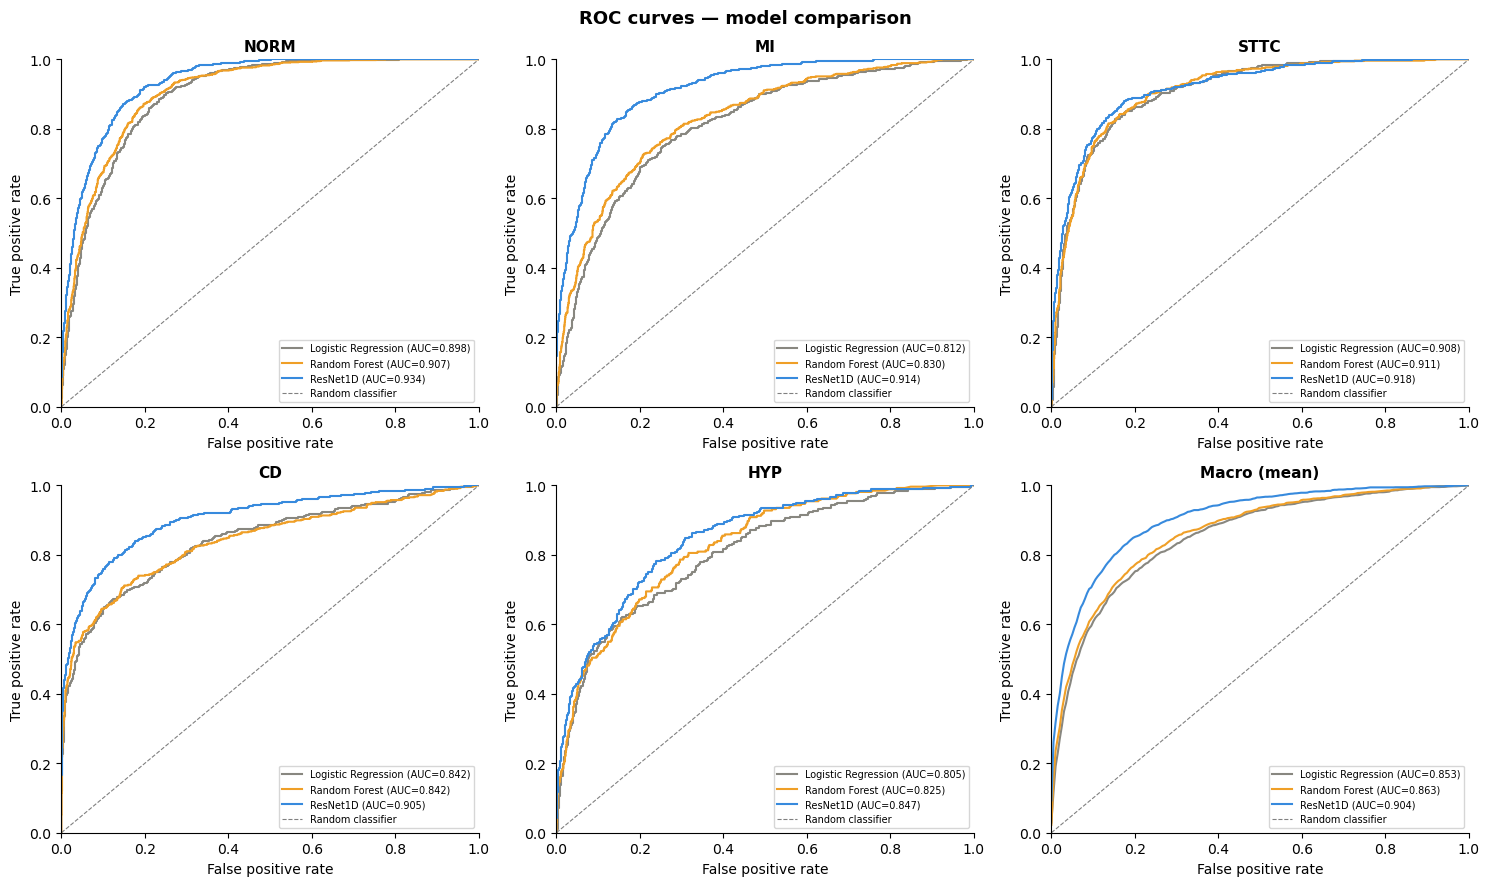

ROC curves saved to artifacts/


In [55]:
model_probs = {
    'Logistic Regression': lr_test_probs,
    'Random Forest':       rf_test_probs,
    'ResNet1D':            resnet_test_probs,
}

fig = plot_roc_curves(test_labels, model_probs, CLASS_ORDER)
plt.show()

# Save
fig.savefig(ARTIFACTS / 'roc_curves.png', dpi=150, bbox_inches='tight')
print("ROC curves saved to artifacts/")